In [1]:
### Packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.special import erfc
import pandas as pd
import glob
import os
import re

# 1st models

## Parameters

In [26]:
### Global variables

# Reflectivity
R0 = 2
c = 0.5

# Definition of V(Q,t)
a0 = -5
tau = 5
a1 = 1
tau1 = 10
a2 = 1
tau2 = 10
b = 0.5

# Equation of motion
d = 0.05 # Damping
Meff = 1 # Effective mass

# Computation parameters
dt = 0.01 # Time quantization
Tstart = -2
Tend = 40 # Total simulation time

In [27]:
def init_params():
    params = {
    "R_0": R0,
    "c_R": c,
    "a_0": a0,
    "tau_0": tau,
    "a_1": a1,
    "tau_1": tau1,
    "a_2": a2,
    "tau_2": tau2,
    "b0": b,
    "damp": d,
    "M": Meff,
    "difft": dt,
    "Ti": Tstart,
    "Tf": Tend
    }
    return params

params = init_params()

## Potential/equation of motion

### Defintion of a(t), potential changes...

In [5]:
### Potential defintion

def a(t):
    a=params["a_0"]
    if t>=0:
        a+=params["a_1"]*np.exp(-t/params["tau_1"])
    if t>=params["tau_0"]:
        a+=params["a_2"]*np.exp(-(t-params["tau_0"])/params["tau_2"])
    return a

print(a(0),a0)

def V(Q,t):
    return a(t)*(Q**2) + b*(Q**4)

def dV(Q,t): # We directly define the potential derivative, avoiding useless computations
    return 2*a(t)*Q + 4*b*(Q**3)

-4.0 -5


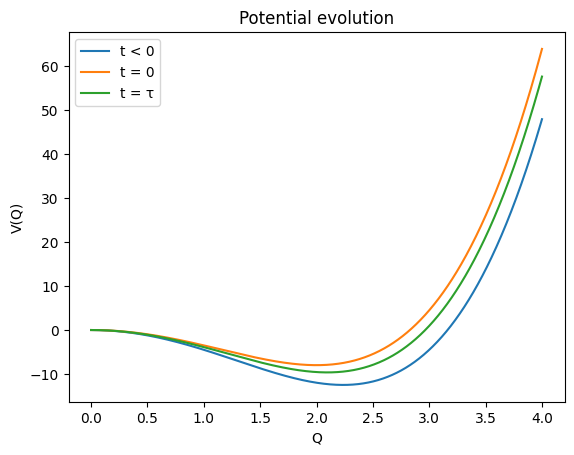

In [6]:
Qex = np.linspace(0,4,1000)

plt.figure()
plt.plot(Qex, V(Qex, -1), label="t < 0")
plt.plot(Qex, V(Qex, 0), label="t = 0")
plt.plot(Qex, V(Qex, params["tau_0"]), label="t = τ")

plt.xlabel("Q")
plt.ylabel("V(Q)")
plt.title("Potential evolution")
plt.legend()

plt.show()

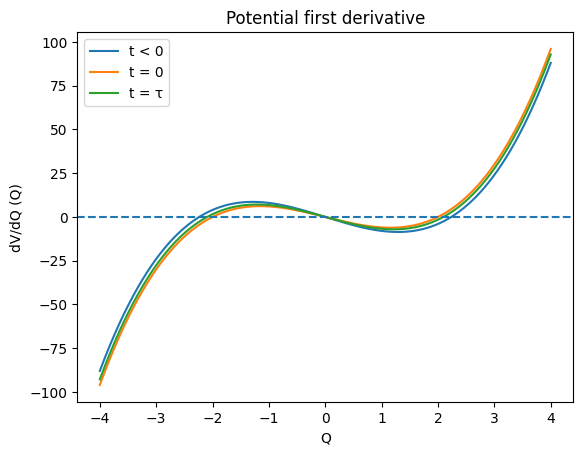

In [7]:
Qex = np.linspace(-4,4,1000)

plt.figure()
plt.plot(Qex, dV(Qex, -1), label="t < 0")
plt.plot(Qex, dV(Qex, 0), label="t = 0")
plt.plot(Qex, dV(Qex, params["tau_0"]), label="t = τ")
plt.axhline(0, linestyle='--')

plt.xlabel("Q")
plt.ylabel("dV/dQ (Q)")
plt.title("Potential first derivative")
plt.legend()

plt.show()

In [8]:
### Computing next value of Q

def update(Q,t): #both Q and t are arrays
    tn = t[-1]+dt
    Qn = (Meff*(2*Q[-1]-Q[-2])-dV(Q[-1],tn)*dt*dt+d*dt*Q[-1])/(Meff+d*dt)
    return Qn,tn


In [9]:
### Whole computation

## Initialization
t = []
tn = Tstart
t.append(tn)
Q0 = [np.sqrt(-a0/(2*b))]
Q = [Q0[0],Q0[0]]

## Main loop
while tn<=Tend:
    Qn,tn = update(Q,t)
    Q.append(Qn)
    t.append(tn)
    Q0.append(np.sqrt(-a(tn)/(2*b)))
Q = Q[1:]
print(len(Q),len(t), len (Q0))


4201 4201 4201


In [10]:
### General defintion 
def compute1():
    ## Initialization
    t = []
    tn = params["Ti"]
    t.append(tn)
    Q0 = [np.sqrt(-params["a_0"]/(2*params["b0"]))]
    Q = [Q0[0],Q0[0]]

    ## Main loop
    while tn<=params["Tf"]:
        Qn,tn = update(Q,t)
        Q.append(Qn)
        t.append(tn)
        Q0.append(np.sqrt(-a(tn)/(2*params["b0"])))
    Q = Q[1:]
    return t,Q,Q0

### Single test

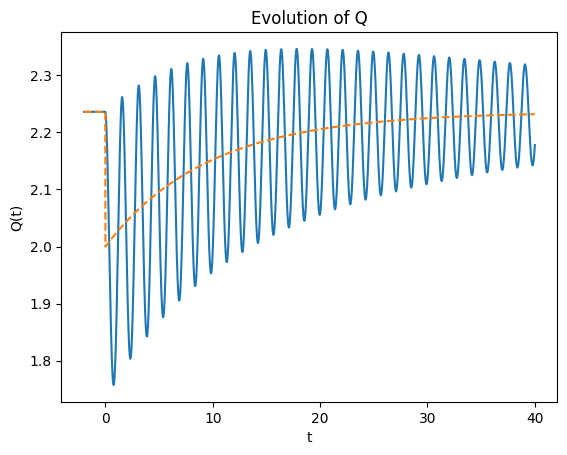

In [11]:
t,Q,Q0 = compute1()

plt.figure()
plt.plot(t, Q)
plt.plot(t, Q0, linestyle='--')

plt.xlabel("t")
plt.ylabel("Q(t)")
plt.title("Evolution of Q")

plt.show()

### Phonon displacement in (Q,V(Q,t)) space

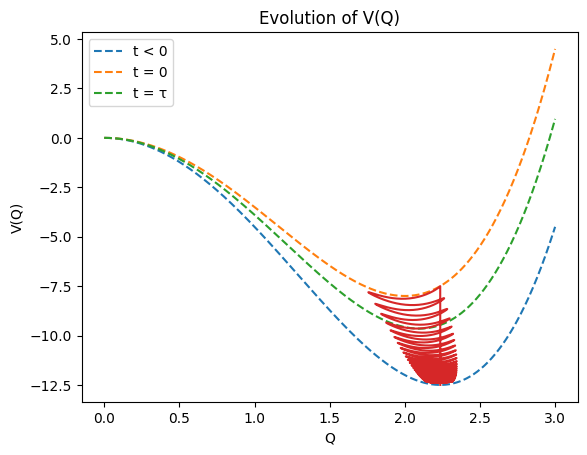

In [12]:
V_Qt = []

for i in range(len(Q)):
    V_Qt.append(V(Q[i],t[i]))

Qex = np.linspace(0,3,1000)
plt.figure()


plt.plot(Qex, V(Qex, -1), label="t < 0", linestyle='--')
plt.plot(Qex, V(Qex, 0), label="t = 0", linestyle='--')
plt.plot(Qex, V(Qex, params["tau_0"]), label="t = τ", linestyle='--')
plt.plot(Q, V_Qt)

plt.xlabel("Q")
plt.ylabel("V(Q)")
plt.title("Evolution of V(Q)")
plt.legend()

plt.show()

# ?

## Removing tau1/tau2 relaxation

In [120]:
### Modify variables

# Definition of V(Q,t)
a0 = -5
tau = 5
a1 = 0.1
tau1 = 10
a2 = 0.1
tau2 = 10
b = 0.5

# Equation of motion
d = 0.0 # Damping
Meff = 1 # Effective mass

# Computation parameters
dt = 0.01 # Time quantization
Tstart = -2
Tend = 40 # Total simulation time

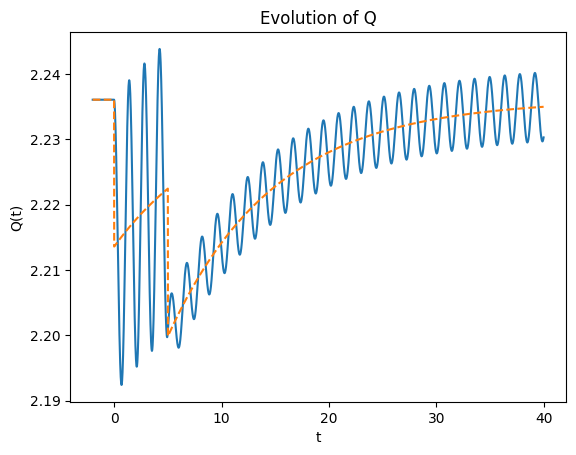

In [121]:
### We first get rid of the second pulse to simplify the fitting
# params["a_2"] = 0

### Reset params
params = init_params()
t,Q,Q0 = compute1()

plt.figure()
plt.plot(t, Q)
plt.plot(t, Q0, linestyle='--')

plt.xlabel("t")
plt.ylabel("Q(t)")
plt.title("Evolution of Q")

plt.show()

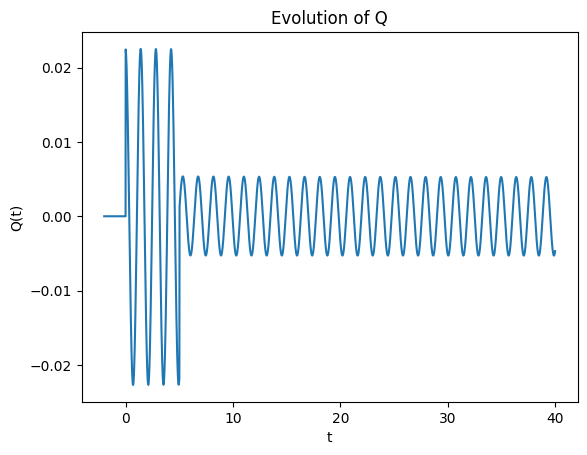

In [122]:
## In this part, we will remove tau1/2 reelaxation without fitting, using only the computation of Q0(t)

t = np.array(t)
Q = np.array(Q)
Q0 = np.array(Q0)


plt.figure()
plt.plot(t, Q - Q0)

plt.xlabel("t")
plt.ylabel("Q(t)")
plt.title("Evolution of Q")

plt.show()

{'R_0': 2, 'c_R': 0.5, 'a_0': -5, 'tau_0': 5, 'a_1': 0.1, 'tau_1': 10, 'a_2': 0.1, 'tau_2': 10, 'b0': 0.5, 'damp': 0.0, 'M': 1, 'difft': 0.01, 'Ti': -2, 'Tf': 40}


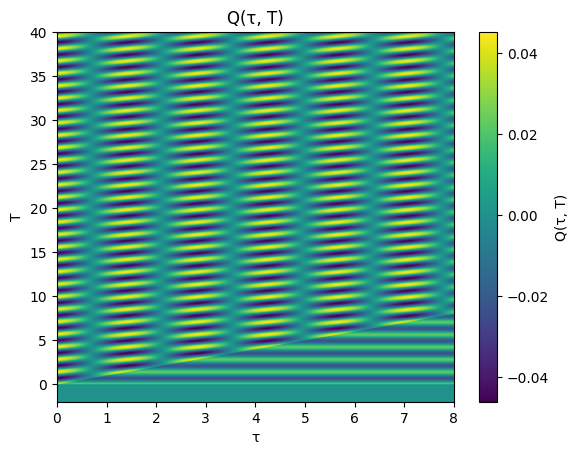

In [123]:
# 2D Map

maxtau = Tend*0.2
taures = 1000

Tres = len(Q)
taurange = np.linspace(0,maxtau,taures)

Q_Ttau = np.zeros((Tres,taures))

params = init_params()
print(params)

for j in range(taures):
    params["tau_0"] = taurange[j]
    t,Q,Q0 = compute1()
    for i in range(len(Q)):
        Q_Ttau[i][j] = Q[i] - Q0[i]

params = init_params()

fig, ax = plt.subplots()

im = ax.imshow(
    Q_Ttau,
    origin="lower",
    extent=[taurange[0], taurange[-1], t[0], t[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Q(τ, T)")

ax.set_xlabel("τ")
ax.set_ylabel("T")
ax.set_title("Q(τ, T)")

plt.show()

In [124]:
# choose starting time (Td for example)
t0 = taurange[-1]
t = np.array(t)
# mask on time axis
mask = t >= t0

# apply window
Q_win = Q_Ttau[mask, :]
t_win = t[mask]

# FFT along T axis (axis=0)
Q_fft_T = np.fft.fft(Q_win, axis=0)

# frequency axis
dt = t_win[1] - t_win[0]
freqs_T = np.fft.fftfreq(len(t_win), d=dt)

# shift
Q_fft_T = np.fft.fftshift(Q_fft_T, axes=0)
freqs_T = np.fft.fftshift(freqs_T)

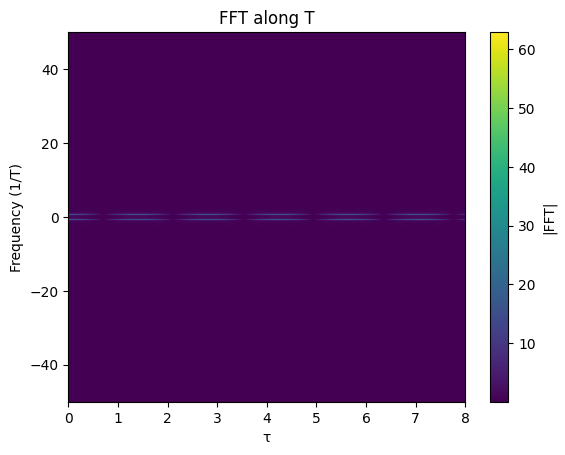

In [125]:
fig, ax = plt.subplots()

im = ax.imshow(
    np.abs(Q_fft_T),
    origin="lower",
    extent=[taurange[0], taurange[-1], freqs_T.min(), freqs_T.max()],
    aspect="auto"
)

plt.colorbar(im, ax=ax, label="|FFT|")
ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title("FFT along T")

plt.show()

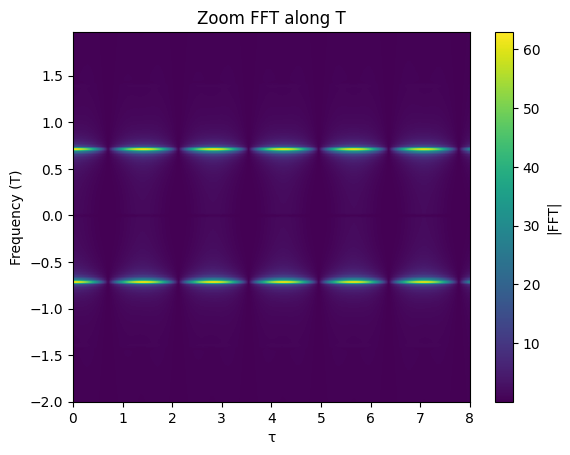

In [126]:
A = np.abs(Q_fft_T)

# frequency step
df_T = freqs_T[1] - freqs_T[0]

# zoom width in frequency units
w_T = 2  # adjust

# convert to index width
i_T = int(w_T / df_T)

# center at zero frequency
c0 = np.argmin(np.abs(freqs_T))

# slice
A_zoom = A[c0 - i_T:c0 + i_T, :]
freqs_T_zoom = freqs_T[c0 - i_T:c0 + i_T]

# plot
fig, ax = plt.subplots()

im = ax.imshow(
    A_zoom,
    origin="lower",
    extent=[taurange[0], taurange[-1],
            freqs_T_zoom[0], freqs_T_zoom[-1]],
    aspect="auto"
)

plt.colorbar(im, ax=ax, label="|FFT|")
ax.set_xlabel("τ")
ax.set_ylabel("Frequency (T)")
plt.title("Zoom FFT along T")

plt.show()

In [131]:
# choose starting time (Td for example)
t0 = taurange[-1]
t = np.array(t)
# mask on time axis
mask = t >= t0

# apply window
Q_win = Q_Ttau[mask, :]
t_win = t[mask]

# FFT along T axis (axis=0)
Q_fft_T = np.fft.fft(Q_win, axis=0)

# FFT on τ axis
Q_fft_2d = np.fft.fft(Q_fft_T, axis=1)

# frequency axis
dt = t_win[1] - t_win[0]
dtau = taurange[1] - taurange[0]

freqs_T = np.fft.fftfreq(len(t_win), d=dt)
freqs_tau = np.fft.fftfreq(len(taurange), d=dtau)

# shift both axes
Q_fft_2d = np.fft.fftshift(Q_fft_2d, axes=(0,1))
freqs_T = np.fft.fftshift(freqs_T)
freqs_tau = np.fft.fftshift(freqs_tau)

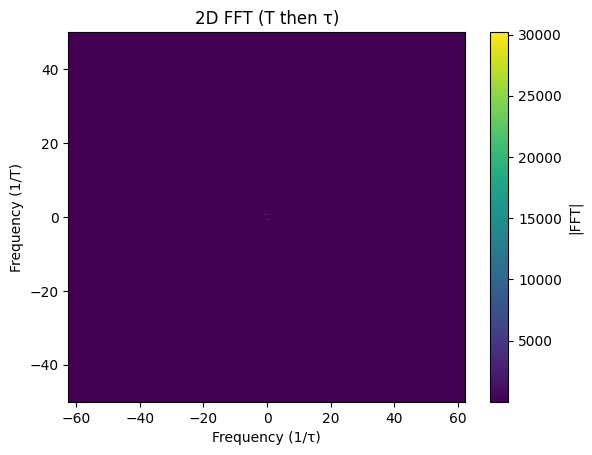

In [132]:
fig, ax = plt.subplots()

im = ax.imshow(
    np.abs(Q_fft_2d),
    origin="lower",
    extent=[freqs_tau.min(), freqs_tau.max(), freqs_T.min(), freqs_T.max()],
    aspect="auto"
)

plt.colorbar(im, ax=ax, label="|FFT|")
ax.set_xlabel("Frequency (1/τ)")
ax.set_ylabel("Frequency (1/T)")
ax.set_title("2D FFT (T then τ)")

plt.show()

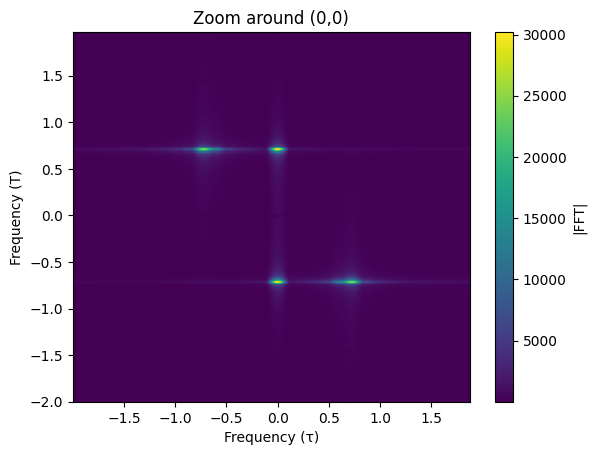

In [133]:
A = np.abs(Q_fft_2d)

# choose zoom window (in frequency units)
df_tau = freqs_tau[1] - freqs_tau[0]
df_T = freqs_T[1] - freqs_T[0]

# half-widths you choose
w_tau = 2
w_T = 2

# convert to index width
i_tau = int(w_tau / df_tau)
i_T = int(w_T / df_T)

# center indices (0 frequency)
c0 = np.argmin(np.abs(freqs_tau))
r0 = np.argmin(np.abs(freqs_T))

# slice
A_zoom = A[r0 - i_T:r0 + i_T, c0 - i_tau:c0 + i_tau]

# frequency axes zoom
freqs_tau_zoom = freqs_tau[c0 - i_tau:c0 + i_tau]
freqs_T_zoom = freqs_T[r0 - i_T:r0 + i_T]

# plot
fig, ax = plt.subplots()

im = ax.imshow(
    A_zoom,
    origin="lower",
    extent=[freqs_tau_zoom[0], freqs_tau_zoom[-1],
            freqs_T_zoom[0], freqs_T_zoom[-1]],
    aspect="auto"
)

plt.colorbar(im, ax=ax, label="|FFT|")
ax.set_xlabel("Frequency (τ)")
ax.set_ylabel("Frequency (T)")
plt.title("Zoom around (0,0)")

plt.show()

## Fitting tests

### Model 1

In [13]:
### Trying to fit omega, tau1 and d (damping) from previous results

delta_Q0 = Q0[-1] - np.sqrt((-a0-a1)/(2*b))

def model1(t, f, t1, d):
    t = np.asarray(t)
    
    return np.where(
        t < 0,
        Q0[-1],
        Q0[-1] - delta_Q0 * np.exp(-t/t1) + delta_Q0 * np.cos(f*t) * np.exp(-d*t)
    )
    
def residuals_explicit(f, t1, d, t, data):
    model_vals = model1(t, f, t1, d)
    return model_vals - data

# fitting requires parameter vector
def residuals_wrapper(x, t, data):
    f, t1, d= x
    return residuals_explicit(f, t1, d, t, data)

# initial guess
x0 = [2,50,0.001]

result = least_squares(
    residuals_wrapper,
    x0,
    args=(t, Q),
    bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
    loss="soft_l1"
)

f_fit, t1_fit, d_fit = result.x

print(f_fit, t1_fit, d_fit)

"""
def model1(t, A, d, f, phi):
    t = np.asarray(t)
    model = Q0[-1] + A * np.exp(-d * t) * np.cos(f * t + phi)
    return np.where(t < 0, Q0[-1], model)

def residuals_explicit(A, d, f, phi, t, data):
    model_vals = model1(t, A, d, f, phi)
    return model_vals - data

def residuals_wrapper(x, t, data):
    A, d, f, phi = x
    return residuals_explicit(A, d, f, phi, t, data)

# initial guess
x0 = [(max(Q) - min(Q))/2, 0.05, 2, 0]

result = least_squares(
    residuals_wrapper,
    x0,
    args=(t, Q),
    bounds=([0, 0, 0, -np.inf], [np.inf, np.inf, np.inf, np.inf]),
    loss="soft_l1"
)

A_fit, d_fit, f_fit, phi_fit = result.x

print(A_fit, d_fit, f_fit, phi_fit)
"""

4.192662775653175 10.779169321919596 0.07420860113307126


'\ndef model1(t, A, d, f, phi):\n    t = np.asarray(t)\n    model = Q0[-1] + A * np.exp(-d * t) * np.cos(f * t + phi)\n    return np.where(t < 0, Q0[-1], model)\n\ndef residuals_explicit(A, d, f, phi, t, data):\n    model_vals = model1(t, A, d, f, phi)\n    return model_vals - data\n\ndef residuals_wrapper(x, t, data):\n    A, d, f, phi = x\n    return residuals_explicit(A, d, f, phi, t, data)\n\n# initial guess\nx0 = [(max(Q) - min(Q))/2, 0.05, 2, 0]\n\nresult = least_squares(\n    residuals_wrapper,\n    x0,\n    args=(t, Q),\n    bounds=([0, 0, 0, -np.inf], [np.inf, np.inf, np.inf, np.inf]),\n    loss="soft_l1"\n)\n\nA_fit, d_fit, f_fit, phi_fit = result.x\n\nprint(A_fit, d_fit, f_fit, phi_fit)\n'

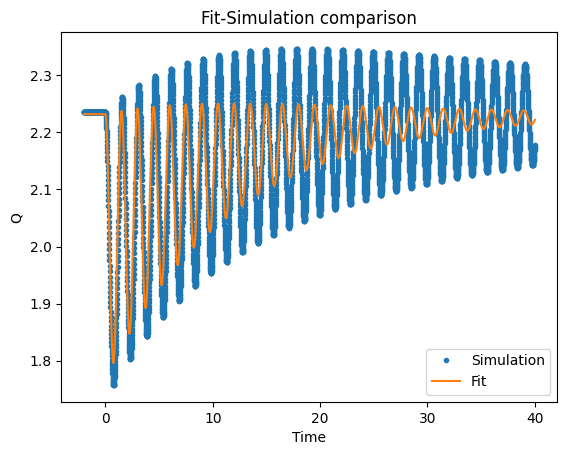

In [14]:
### Comparison between simulation and model

Q_model = model1(t, f_fit, t1_fit, d_fit) ### issue with damping fitting...

# Plot
plt.figure()
plt.plot(t, Q, '.', label="Simulation")
plt.plot(t, Q_model, '-', label="Fit")
plt.xlabel("Time")
plt.ylabel("Q")
plt.legend()
plt.title("Fit-Simulation comparison")
plt.show()

### Model 2

In [15]:
### Trying to fit omega, tau1 and d (damping) from previous results

delta_Q0 = Q0[-1] - np.sqrt((-a0-a1)/(2*b))
params = init_params()

def model_a(t, tau, a1):
    a0 = params["a_0"]
    t = np.asarray(t)
    return a0 + np.where(t >= 0, a1*np.exp(-t/tau), 0) ## This evolution of a is modelled (for a single pulse) using an amplitude and the tau relaxation time

def omega_a(a):
    return np.sqrt(-4*a/1) ## We use 1 as the effective mass

def delta_Q(a): ## We compute the equilibrium position using the model_a
    return Q0[-1] - np.sqrt(-a/(2*b))


def model2(t, t1, d, a1):
    t = np.asarray(t)
    a = model_a(t,t1,a1)

    return np.where(
        t < 0,
        Q0[-1],
        Q0[-1] - delta_Q(a) + delta_Q0 * np.cos(omega_a(a)*t) * np.exp(-d*t)
    )
    
def residuals_explicit2(t1, d, a1, t, data):
    model_vals = model2(t, t1, d, a1)
    return model_vals - data

# fitting requires parameter vector
def residuals_wrapper2(x, t, data):
    t1, d, a1= x
    return residuals_explicit2(t1, d, a1, t, data)

# initial guess (close to real)
x0 = [9,0.08,1.3]

# Expected values are 10, 0.05, 1
x_th = [10,0.024,1]

result = least_squares(
    residuals_wrapper2,
    x0,
    args=(t, Q),
    bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
    loss="soft_l1"
)

t1_fit, d_fit, a1_fit = result.x
print(t1_fit, d_fit, a1_fit)

t1_th, d_th, a1_th = x_th
print(t1_th, d_th, a1_th)

31.71483802394679 0.024650675228603088 0.8987710199627151
10 0.024 1


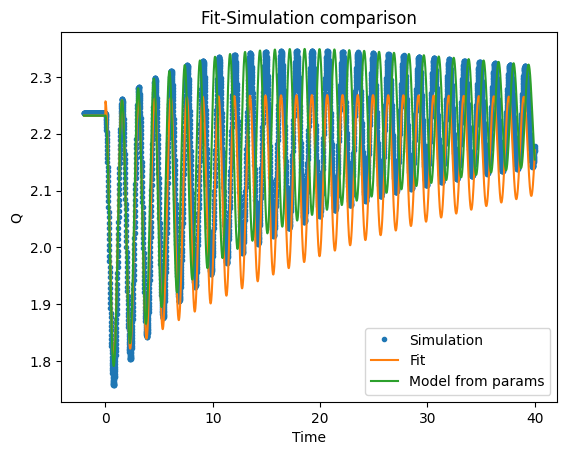

In [16]:
### Comparison between simulation and model

Q_model = model2(t, t1_fit, d_fit, a1_fit)
Q_th = model2(t, t1_th, d_th, a1_th)

# Plot
plt.figure()
plt.plot(t, Q, '.', label="Simulation")
plt.plot(t, Q_model, '-', label="Fit")
plt.plot(t, Q_th, '-', label="Model from params")
plt.xlabel("Time")
plt.ylabel("Q")
plt.legend()
plt.title("Fit-Simulation comparison")
plt.show()

### Conclusion : Model 2 is off regarding the t1 parameter
### Next idea : separate frequency evolution and pulse amplitude

### Model 3

In [17]:
### Trying to fit omega, tau1 and d (damping) from previous results

delta_Q0 = Q0[-1] - np.sqrt((-a0-a1)/(2*b))
params = init_params()

def model_a(t, tau, a1):
    a0 = params["a_0"]
    t = np.asarray(t)
    return a0 + np.where(t >= 0, a1*np.exp(-t/tau), 0)

def omega_a(a):
    return np.sqrt(-4*a/1)

def delta_Q(a):
    return Q0[-1] - np.sqrt(-a/(2*b))

def phase_from_omega(t, omega):
    dt1 = np.gradient(t)
    return np.cumsum(omega * dt1) + np.pi

def model3(t, t1, d, a1, phi_0):
    t = np.asarray(t)
    a = model_a(t, t1, a1)
    a = np.minimum(a, -1e-12)
    omega = omega_a(a)
    phi = phase_from_omega(t, omega)

    return np.where(
        t < 0,
        Q0[-1],
        Q0[-1] - delta_Q(a) + delta_Q0 * np.cos(phi + phi_0) * np.exp(-d*t)
    )

def residuals_explicit3(t1, d, a1, phi_0, t, data):
    model_vals = model3(t, t1, d, a1, phi_0)
    return model_vals - data

def residuals_wrapper3(x, t, data):
    t1, d, a1, phi_0= x
    return residuals_explicit3(t1, d, a1, phi_0, t, data)

x0 = [9,0.08,1.3,0]

x_th = [10,0.024,1,np.pi]

result = least_squares(
    residuals_wrapper3,
    x0,
    args=(t, Q),
    bounds=([0, 0, 0, -np.inf], [np.inf, np.inf, np.inf, np.inf]),
    loss="soft_l1"
)

t1_fit, d_fit, a1_fit, phi0_fit = result.x
print(t1_fit, d_fit, a1_fit, phi0_fit)

t1_th, d_th, a1_th, phi0_th = x_th
print(t1_th, d_th, a1_th, phi0_th)

10.68500359513661 0.02350337199127109 1.08272098450944 0.5120487574518044
10 0.024 1 3.141592653589793


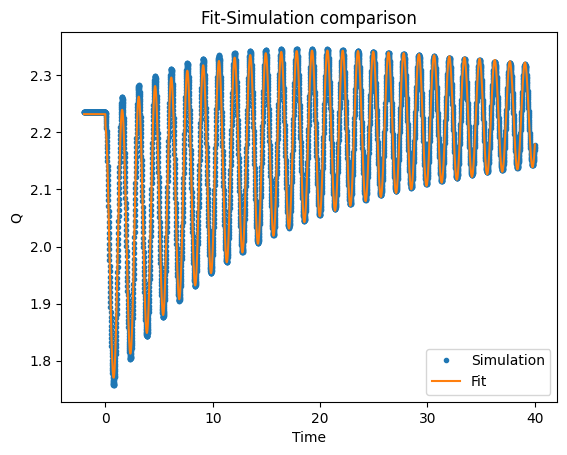

In [18]:
### Comparison between simulation and model

Q_model = model3(t, t1_fit, d_fit, a1_fit, phi0_fit)
Q_th = model3(t, t1_th, d_th, a1_th, phi0_th)

# Plot
plt.figure()
plt.plot(t, Q, '.', label="Simulation")
plt.plot(t, Q_model, '-', label="Fit")
#plt.plot(t, Q_th, '-', label="Model from params")
plt.xlabel("Time")
plt.ylabel("Q")
plt.legend()
plt.title("Fit-Simulation comparison")
plt.show()

### Model 3 is the most accurate so far
### TODO: extend it for 2 pulses

## Simulation

### 2D Map (t and f)

{'R_0': 2, 'c_R': 0.5, 'a_0': -5, 'tau_0': 5, 'a_1': 1, 'tau_1': 10, 'a_2': 1, 'tau_2': 10, 'b0': 0.5, 'damp': 0.05, 'M': 1, 'difft': 0.01, 'Ti': -2, 'Tf': 40}


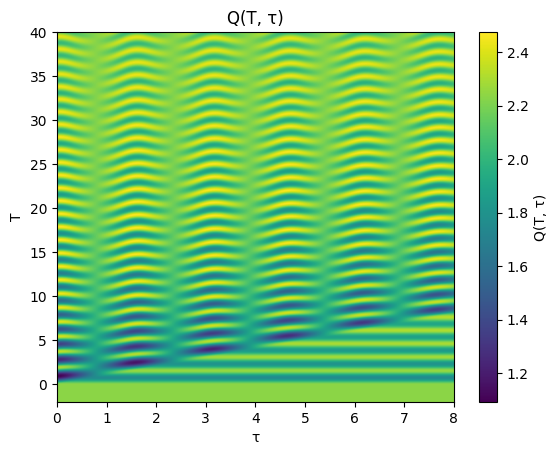

In [19]:
# 2D Map

maxtau = Tend*0.2
taures = 1000

Tres = len(Q)
taurange = np.linspace(0,maxtau,taures)

Q_Ttau = np.zeros((Tres,taures))

params = init_params()
print(params)

for j in range(taures):
    params["tau_0"] = taurange[j]
    t,Q,Q0 = compute1()
    for i in range(len(Q)):
        Q_Ttau[i][j] = Q[i]

params = init_params()

fig, ax = plt.subplots()

im = ax.imshow(
    Q_Ttau,
    origin="lower",
    extent=[taurange[0], taurange[-1], t[0], t[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Q(T, τ)")

ax.set_xlabel("τ")
ax.set_ylabel("T")
ax.set_title("Q(T, τ)")

plt.show()

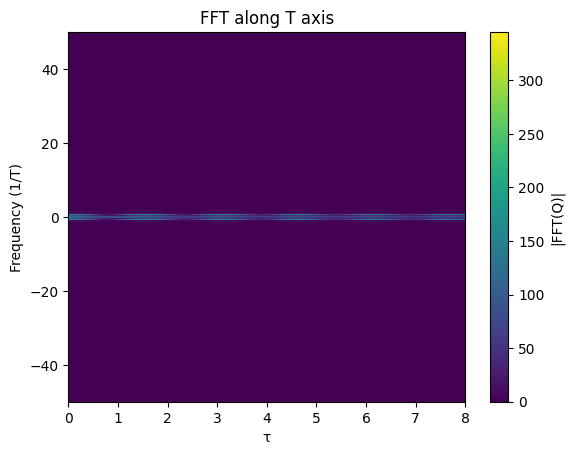

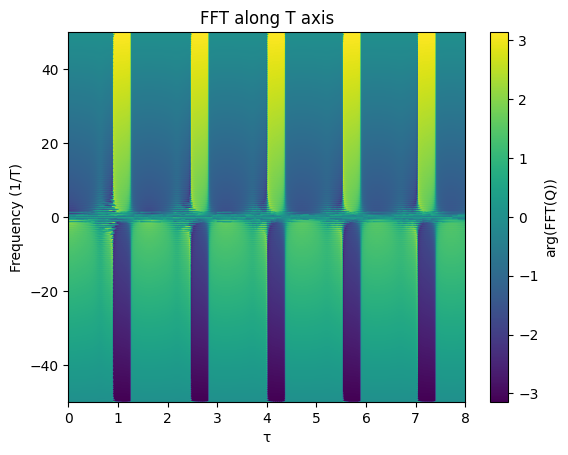

In [20]:
### FFT from previous 2D map (along T)

# Remove DC component (mean along T axis)
Q_centered = Q_Ttau - np.mean(Q_Ttau, axis=0, keepdims=True)

fft_Q = np.fft.fft(Q_centered, axis=0)

# Compute the corresponding frequency axis for T
freq_T = np.fft.fftfreq(len(t), d=dt)

# Shift zero frequency to the center for better visualization
fft_Q_shifted = np.fft.fftshift(fft_Q, axes=0)
freq_T_shifted = np.fft.fftshift(freq_T)



# Plot the magnitude of the FFT
fig, ax = plt.subplots()

im = ax.imshow(
    np.abs(fft_Q_shifted),  # magnitude of the FFT
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_T_shifted[0], freq_T_shifted[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("|FFT(Q)|")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title("FFT along T axis")

plt.show()

# Plot the phase of the FFT
fig, ax = plt.subplots()

im = ax.imshow(
    np.angle(fft_Q_shifted),  # phase of the FFT
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_T_shifted[0], freq_T_shifted[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("arg(FFT(Q))")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title("FFT along T axis")

plt.show()

### 2 pulse - 1 pulse measurement

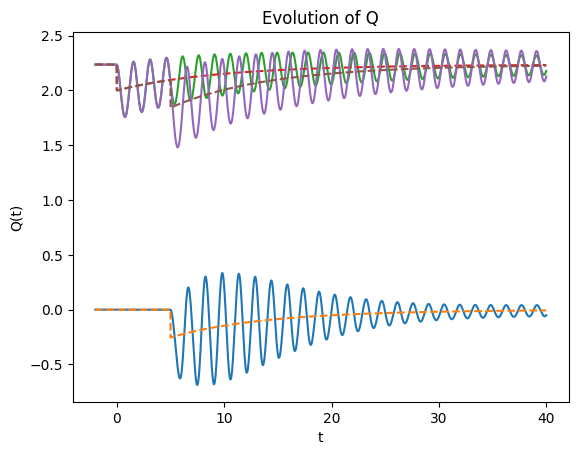

In [21]:
### 2 pulse - 1 pulse

params = init_params()
t2,Q2,Q02 = compute1()
params["a_2"] = 0
t1,Q1,Q01 = compute1()
params = init_params()
t = t2
Q = np.array(Q2) - np.array(Q1)
Q0 = np.array(Q02) - np.array(Q01)

plt.figure()
plt.plot(t, Q)
plt.plot(t, Q0, linestyle='--')
plt.plot(t, Q1)
plt.plot(t, Q01, linestyle='--')
plt.plot(t, Q2)
plt.plot(t, Q02, linestyle='--')

plt.xlabel("t")
plt.ylabel("Q(t)")
plt.title("Evolution of Q")

plt.show()


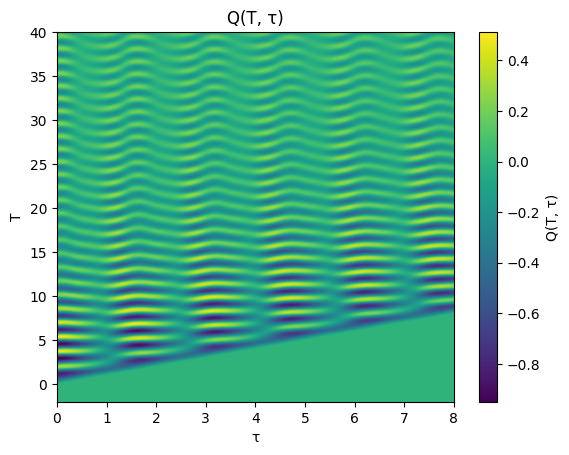

In [22]:
### 2 pulse - 1 pulse : 2D map

maxtau = Tend*0.2
taures = 1000

Tres = len(Q)
taurange = np.linspace(0,maxtau,taures)

Q_Ttau = np.zeros((Tres,taures))

params = init_params()

for j in range(taures):
    params["tau_0"] = taurange[j]
    t2,Q2,Q02 = compute1()
    params["a_2"] = 0
    t1,Q1,Q01 = compute1()
    params = init_params()
    Q = np.array(Q2) - np.array(Q1)
    for i in range(len(Q)):
        Q_Ttau[i][j] = Q[i]


params = init_params()

fig, ax = plt.subplots()

im = ax.imshow(
    Q_Ttau,
    origin="lower",
    extent=[taurange[0], taurange[-1], t[0], t[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Q(T, τ)")

ax.set_xlabel("τ")
ax.set_ylabel("T")
ax.set_title("Q(T, τ)")

plt.show()

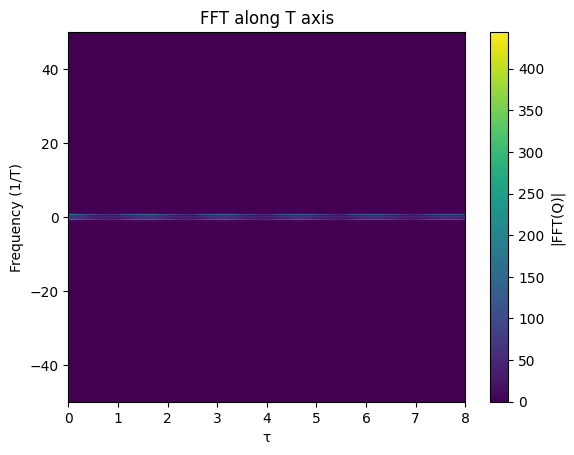

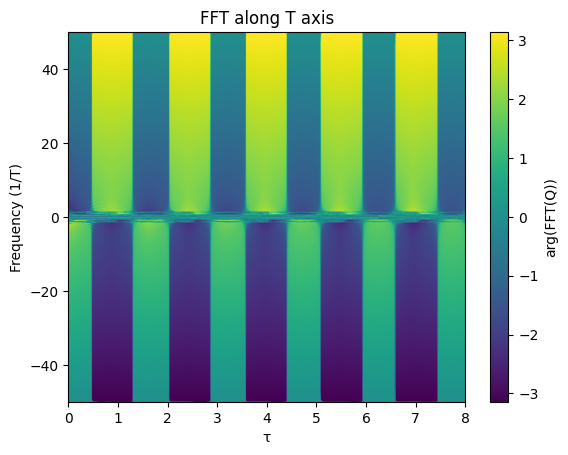

In [23]:
### FFT from previous 2D map (along T)

# Remove DC component (mean along T axis)
Q_centered = Q_Ttau - np.mean(Q_Ttau, axis=0, keepdims=True)

fft_Q = np.fft.fft(Q_centered, axis=0)

# Compute the corresponding frequency axis for T
freq_T = np.fft.fftfreq(len(t), d=dt)

# Shift zero frequency to the center for better visualization
fft_Q_shifted = np.fft.fftshift(fft_Q, axes=0)
freq_T_shifted = np.fft.fftshift(freq_T)



# Plot the magnitude of the FFT
fig, ax = plt.subplots()

im = ax.imshow(
    np.abs(fft_Q_shifted),  # magnitude of the FFT
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_T_shifted[0], freq_T_shifted[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("|FFT(Q)|")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title("FFT along T axis")

plt.show()

# Plot the phase of the FFT
fig, ax = plt.subplots()

im = ax.imshow(
    np.angle(fft_Q_shifted),  # phase of the FFT
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_T_shifted[0], freq_T_shifted[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("arg(FFT(Q))")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title("FFT along T axis")

plt.show()

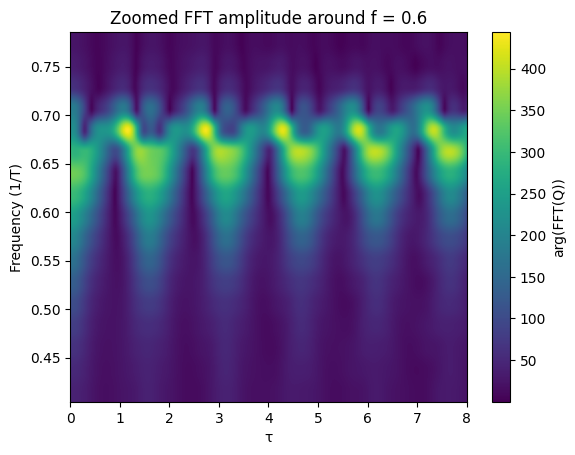

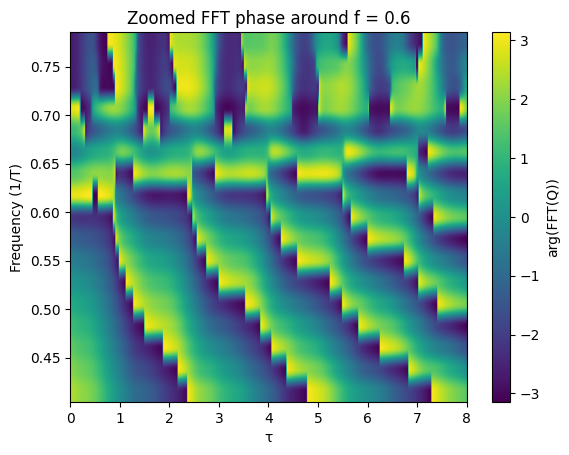

In [24]:
### Zoom around a given frequency
f0 = 0.6
df = 0.2

mask = (freq_T_shifted >= f0 - df) & (freq_T_shifted <= f0 + df)

freq_zoom = freq_T_shifted[mask]
fft_zoom = fft_Q_shifted[mask, :]

amplitude_zoom = np.abs(fft_zoom)
phase_zoom = np.angle(fft_zoom)

phase_zoom = np.where(amplitude_zoom > 1e-6, phase_zoom, np.nan)

###Amplitude zoom
fig, ax = plt.subplots()

im = ax.imshow(
    amplitude_zoom,
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_zoom[0], freq_zoom[-1]],
    aspect="auto",
    #cmap="twilight"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("arg(FFT(Q))")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title(f"Zoomed FFT amplitude around f = {f0}")

plt.show()

### Phase zoom
fig, ax = plt.subplots()

im = ax.imshow(
    phase_zoom,
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_zoom[0], freq_zoom[-1]],
    aspect="auto",
    #cmap="twilight"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("arg(FFT(Q))")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title(f"Zoomed FFT phase around f = {f0}")

plt.show()

# Data analysis

## Extracting data

In [9]:
### The data will be extracted from csv files

files = glob.glob("data/*/scan_*.csv")

dfs = {}

for file in files:
    filename = os.path.basename(file)
    time_code = filename.replace("scan_", "").replace(".csv", "")
    
    dfs[time_code] = pd.read_csv(file)

In [10]:
### First analysis of the data strucure

dfs["20260331_154135"].head()

# final_result correspond to an average of the observed results, each scan contains 100 points and measure 5 parameters :
# pos, pumped, unpumped, pumped std and unpumped std

,final_result,final_result_std,stage_actual_pos_scan1,value_pumped_diode0_scan1,value_unpumped_diode0_scan1,std_pumped_diode0_scan1,std_unpumped_diode0_scan1,stage_actual_pos_scan2,value_pumped_diode0_scan2,value_unpumped_diode0_scan2,...,stage_actual_pos_scan4,value_pumped_diode0_scan4,value_unpumped_diode0_scan4,std_pumped_diode0_scan4,std_unpumped_diode0_scan4,stage_actual_pos_scan5,value_pumped_diode0_scan5,value_unpumped_diode0_scan5,std_pumped_diode0_scan5,std_unpumped_diode0_scan5
0,0.001550,0.001255,55.100,0.317394,0.316917,0.000564,0.000612,55.100,0.317520,0.317018,...,55.100,0.317724,0.317224,0.000647,0.000680,55.100,0.317864,0.317339,0.000534,0.000603
1,0.001567,0.001265,55.105,0.317479,0.316992,0.000603,0.000615,55.105,0.317287,0.316754,...,55.105,0.317785,0.317294,0.000633,0.000668,55.105,0.317713,0.317237,0.000579,0.000644
2,0.001579,0.001276,55.110,0.317360,0.316915,0.000595,0.000676,55.110,0.317539,0.316998,...,55.110,0.317810,0.317328,0.000608,0.000653,55.110,0.318287,0.317764,0.000553,0.000655
3,0.001563,0.001247,55.115,0.317348,0.316868,0.000589,0.000648,55.115,0.317796,0.317301,...,55.115,0.317409,0.316861,0.000644,0.000680,55.115,0.318154,0.317671,0.000586,0.000643
4,0.001593,0.001370,55.120,0.317235,0.316728,0.000717,0.000781,55.120,0.317677,0.317178,...,55.120,0.317050,0.316581,0.000725,0.000751,55.120,0.318059,0.317553,0.000683,0.000738


In [11]:
### Reading excel files to extract experimental conditions
ds_file = "data/LabNotebook_800_400_GeTe_100nm_BaF2_double_pump.xlsx"
dss = pd.read_excel(ds_file, sheet_name="Sample 1")
dss.head()

,Date,Start T,End T,Set T (C),Read T (C),Rate T (C/min),Sample spot,Power probe (mW),Fluence pump (mJ/cm2),fluence pump 2 (mJ/cm2),...,pump 2,Av.,Data code,WP angle,P (pump),P (pump 2),fluence probe (mJ/cm2),File Name,Comment,absorbed fluence pump (mJ/cm2)
0,2026-04-27,NaN,NaN,21.0,NaN,NaN,NaN,0.004,8.0,5.0,...,NaN,NaN,NaN,NaN,1.017876,0.302378,0.335063,scan_20260427_.csv,NaN,NaN
1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0.004,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,scan_19000100_.csv,NaN,NaN
2,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0.002,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,scan_19000100_.csv,NaN,NaN
3,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0.002,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,scan_19000100_.csv,NaN,NaN
4,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,scan_19000100_.csv,NaN,NaN


In [12]:
## Extract timecode from xlsx file
col = "File Name"  
dss["timecode"] = dss[col].str.extract(r"(\d{8}_\d{6})")

In [13]:
# Create meta variable to store info about each measurement
meta = dss.set_index("timecode")

meta.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, nan to nan
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Date                            28 non-null     datetime64[ns]
 1   Start T                         0 non-null      float64       
 2   End T                           0 non-null      float64       
 3   Set T (C)                       27 non-null     float64       
 4   Read T (C)                      0 non-null      float64       
 5   Rate T (C/min)                  0 non-null      float64       
 6   Sample spot                     14 non-null     object        
 7   Power probe (mW)                30 non-null     float64       
 8   Fluence pump (mJ/cm2)           31 non-null     float64       
 9   fluence pump 2 (mJ/cm2)         27 non-null     float64       
 10  start stage                     27 non-null     object        
 11  stop stage

In [14]:
### Compute time_shift from data, for each measurement

time_shifts = {}
x0 = 13.07 # What is assumed to be the zero-delay position

meta.columns = meta.columns.str.strip()
meta["stage 2 position"] = pd.to_numeric(meta["stage 2 position"], errors="coerce")
#meta = meta.dropna(subset=["stage 2 position"])
# meta = meta.groupby(meta.index).first()

for key in dfs.keys():
    if key not in meta.index:
        continue

    x = meta.loc[key, "stage 2 position"]

    time_shift = ((x - x0) * 1e-3) * 2 / (3e8)

    time_shifts[key] = time_shift

for key, val in sorted(time_shifts.items()):
    print(key, "→", val)

20260428_121820 → -1.333333333333305e-13
20260428_122914 → -1.333333333333305e-13
20260428_123936 → -1.333333333333305e-13
20260428_142947 → -1.333333333333305e-13
20260428_143946 → -1.333333333333305e-13
20260428_150055 → -1.333333333333305e-13
20260428_151524 → -1.333333333333305e-13
20260428_152616 → -1.333333333333305e-13
20260428_155023 → -1.333333333333305e-13
20260428_185602 → -1.333333333333305e-13
20260428_191256 → -1.333333333333305e-13
20260428_193057 → -1.333333333333305e-13
20260428_202433 → -1.333333333333305e-13
20260428_203623 → nan
20260430_093102 → -1.333333333333305e-13
20260430_093902 → -1.333333333333305e-13
20260430_095421 → -1.333333333333305e-13
20260430_101013 → -1.333333333333305e-13
20260430_111424 → -2.000000000000076e-13
20260430_113136 → -1.333333333333305e-13
20260430_132237 → nan
20260430_152335 → 0.0
20260430_153110 → 0.0
20260430_154251 → 0.0


In [15]:
### Compute s_final_result for switched pumped/unpumped

for time_code, df in dfs.items():
    
    scan_numbers = sorted({
        int(re.search(r'scan(\d+)', col).group(1))
        for col in df.columns if 'scan' in col
    })
    
    for i in scan_numbers:
        pumped_col = f"value_pumped_diode0_scan{i}"
        unpumped_col = f"value_unpumped_diode0_scan{i}"
        new_col = f"s_result_scan{i}"
        
        # remove if already exists
        if new_col in df.columns:
            df.drop(columns=new_col, inplace=True)
        
        # compute s
        s = (df[unpumped_col] - df[pumped_col]) / df[pumped_col].replace(0, np.nan)
        
        # find insertion index
        cols = list(df.columns)
        insert_pos = max(j for j, col in enumerate(cols) if f"scan{i}" in col) + 1
        
        # insert column
        df.insert(insert_pos, new_col, s)
    
for time_code, df in dfs.items():
    
    # get all s_result columns
    s_cols = [col for col in df.columns if col.startswith("s_result_scan")]
    
    # compute mean across scans (row-wise)
    df["s_final_result"] = df[s_cols].mean(axis=1)
    
    # move column next to final_result
    col_data = df.pop("s_final_result")
    insert_pos = df.columns.get_loc("final_result") + 1
    df.insert(insert_pos, "s_final_result", col_data)

In [16]:
### Compute times from stage_pos_scan1

for time_code, df in dfs.items():
    
    # compute time
    x = df.get("stage_actual_pos_scan1", df.get("stage1_actual_pos_scan1"))
    t = ((x - x[0])*(10**(-3)))*2/(3*(10**8))

    df.insert(0, "time", t)

In [17]:
dfs["20260428_122914"].head()

,time,final_result,s_final_result,final_result_std,stage1_target,stage2_target,stage1_actual_pos_scan1,stage2_actual_pos_scan1,value_pumped_diode0_scan1,value_unpumped_diode0_scan1,...,std_pumped_diode0_scan2,std_unpumped_diode0_scan2,s_result_scan2,stage1_actual_pos_scan3,stage2_actual_pos_scan3,value_pumped_diode0_scan3,value_unpumped_diode0_scan3,std_pumped_diode0_scan3,std_unpumped_diode0_scan3,s_result_scan3
0,0.000000e+00,-0.000271,0.000271,0.004754,59.100,0.0,59.100,NaN,1.649031,1.649005,...,0.010375,0.010589,0.000607,59.100,NaN,1.645084,1.645448,0.009096,0.009353,0.000221
1,3.333333e-14,-0.000343,0.000343,0.004574,59.105,0.0,59.105,NaN,1.646192,1.647192,...,0.010066,0.009316,0.000076,59.105,NaN,1.644616,1.645187,0.008927,0.008581,0.000347
2,6.666667e-14,-0.000418,0.000418,0.004590,59.110,0.0,59.110,NaN,1.648964,1.649727,...,0.009718,0.009322,0.000404,59.110,NaN,1.645233,1.645870,0.009083,0.009141,0.000387
3,1.000000e-13,-0.000434,0.000434,0.004490,59.115,0.0,59.115,NaN,1.650168,1.649994,...,0.008560,0.009752,0.000710,59.115,NaN,1.644645,1.645795,0.009107,0.009150,0.000699
4,1.333333e-13,-0.000077,0.000077,0.004599,59.120,0.0,59.120,NaN,1.648882,1.648698,...,0.009318,0.009620,0.000194,59.120,NaN,1.646899,1.647144,0.009274,0.009197,0.000149


In [22]:
## Both datas are extracted, we now choose references for pump 1 and 2

ref1 = "20260430_101013"
ref2 = "20260430_093902"

ref_t_shift = time_shifts[ref2]
print(ref_t_shift)



-1.333333333333305e-13


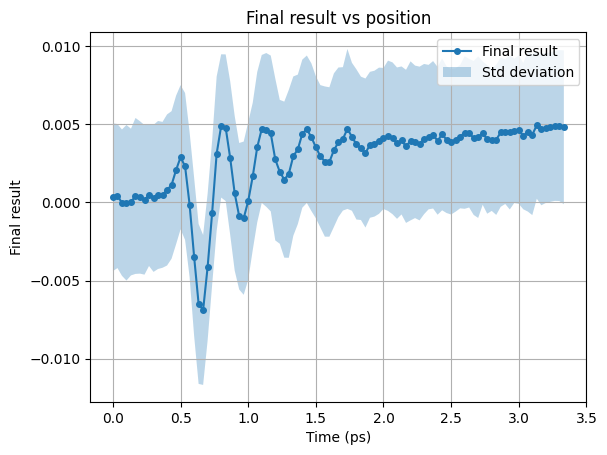

In [19]:
# Select which data to use
df = dfs["20260428_123936"]

# Use one position column (assuming all scans share the same positions)
t = df["time"]*10**12

# Global result and its standard deviation
y = df["s_final_result"]
yerr = df["final_result_std"] ### Warning : the new std wasn't computed

# Create figure
plt.figure()

# Plot the main curve (line + markers)
plt.plot(t, y, 'o-', markersize=4, label="Final result")

# Plot shaded error region (y ± std)
plt.fill_between(
    t,
    y - yerr,
    y + yerr,
    alpha=0.3,   # transparency
    label="Std deviation"
)

# Labels and title
plt.xlabel("Time (ps)")
plt.ylabel("Final result")
plt.title("Final result vs position")

# Legend and grid
plt.legend()
plt.grid()

# Show plot
plt.show()

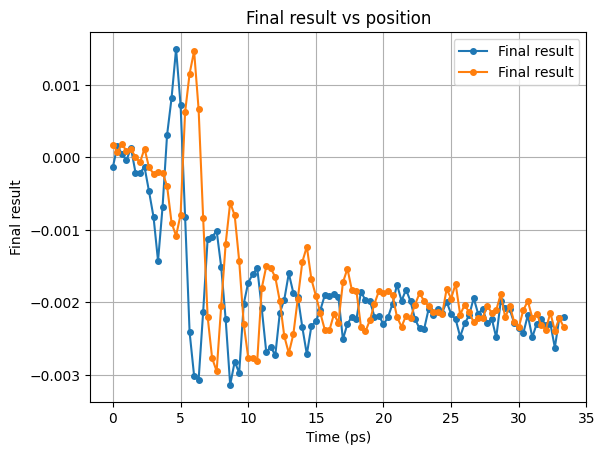

In [ ]:
### Multiple plot

# Select which data to use
keys = [ref1, ref2]



t_list=[]
y_list=[]
yerr_list=[]

for key in keys:
    df = dfs[key]

    # Use one position column (assuming all scans share the same positions)
    t_list.append(df["time"])

    # Global result and its standard deviation
    y_list.append(df["final_result"])
    yerr_list.append(df["final_result_std"]) ### Warning : the new std wasn't computed


# Create figure
plt.figure()

for i in range(len(keys)):

    #Retrieve data
    t=t_list[i] # + time_shift[i]
    y=y_list[i]
    yerr = yerr_list[i]

    # Plot the main curve (line + markers)
    plt.plot(t*10e12, y, 'o-', markersize=4, label="Final result")

    # Plot shaded error region (y ± std)
    #plt.fill_between(
    #t,
    #y - yerr,
    #y + yerr,
    #alpha=0.3,   # transparency
    #label="Std deviation"
    #)

# Labels and title
plt.xlabel("Time (ps)")
plt.ylabel("Final result")
plt.title("Final result vs position")

# Legend and grid
plt.legend()
plt.grid()

# Show plot
plt.show()  

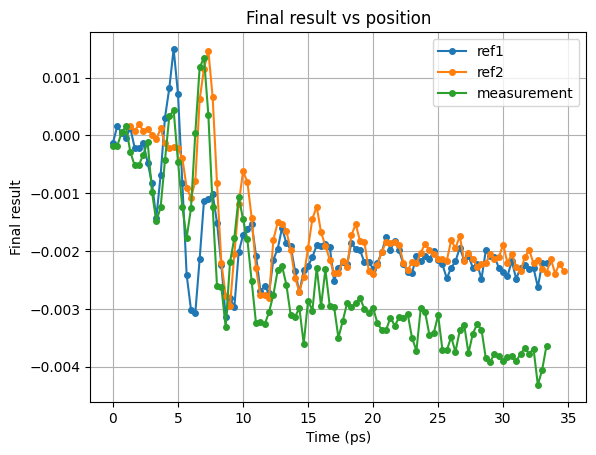

In [25]:
### Print double pump measurements with the 2 single pump pulses

# Select which data to use
measurement = "20260430_111424"
keys = [ref1, ref2, measurement]
labels = ["ref1", "ref2", "measurement"]



t_list=[]
y_list=[]
yerr_list=[]

for key in keys:
    df = dfs[key]

    # Use one position column (assuming all scans share the same positions)
    t_list.append(df["time"])

    # Global result and its standard deviation
    y_list.append(df["final_result"])
    yerr_list.append(df["final_result_std"]) ### Warning : the new std wasn't computed


# Create figure
plt.figure()

for i in range(len(keys)):

    #Retrieve data
    t=t_list[i] # + time_shift[i]
    y=y_list[i]
    yerr = yerr_list[i]

    if i==1: #only for ref2
        t += (ref_t_shift-time_shifts[measurement])

    # Plot the main curve (line + markers)
    plt.plot(t*10e12, y, 'o-', markersize=4, label=labels[i])

    # Plot shaded error region (y ± std)
    #plt.fill_between(
    #t,
    #y - yerr,
    #y + yerr,
    #alpha=0.3,   # transparency
    #label="Std deviation"
    #)

# Labels and title
plt.xlabel("Time (ps)")
plt.ylabel("Final result")
plt.title("Final result vs position")

# Legend and grid
plt.legend()
plt.grid()

# Show plot
plt.show()  

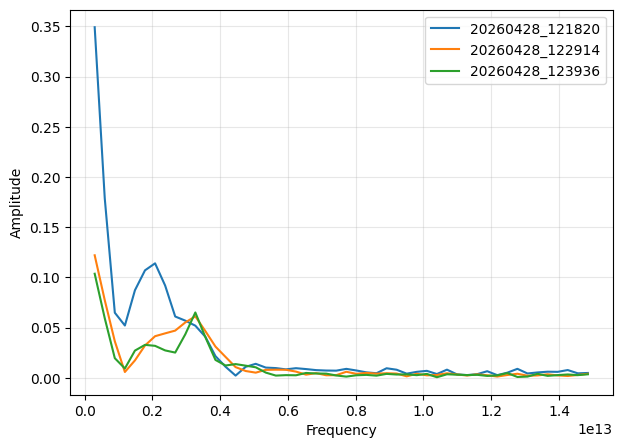

In [40]:
### FFT of data (extracting oscillations frequency)

fig, ax = plt.subplots(figsize=(7,5))

for x, y, key in zip(t_list, y_list, keys):
    t = np.array(t)
    y = np.array(y)

    dt = t[1]-t[0]
    y_centered = y - np.mean(y)

    # FFT
    fft_vals = np.fft.fft(y_centered)
    freq = np.fft.fftfreq(len(t), d=dt)

    
    mask = freq > 0
    freq = freq[mask]
    amp = np.abs(fft_vals[mask])

    ax.plot(freq, amp, label=key)

ax.set_xlabel("Frequency")
ax.set_ylabel("Amplitude")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Fitting the data from previous model


In [30]:
### We define an alternative version of a, taking into account the gaussian shape of the pulse, for both 1 and 2 pulses

from scipy.special import erfc

def model_a_conv1(t, a0, a1, tau1, sigma, t0):
    t = np.array(t)

    term = (a1 / 2) * np.exp(
        (sigma**2) / (2 * tau1**2) - (t - t0) / tau1
    ) * erfc(
        (sigma**2 - tau1 * (t - t0)) / (np.sqrt(2) * sigma * tau1)
    )

    return a0 + term


### Model 3 from earlier

# delta_Q0 = Q0[-1] - np.sqrt((-a0-a1)/(2*b)) ## Q0[-1] and b has to become a parameter
params = init_params()

# model_a is replaced by model_a_conv1

def omega_a(a):
    return np.sqrt(-4*a/1)

def delta_Q(a,Q0,b):
    return Q0 - np.sqrt(-a/(2*b))

def phase_from_omega(t, omega):
    dt1 = np.gradient(t)
    return np.cumsum(omega * dt1) + np.pi

def model3(t, t1, d, a1, phi_0, t0, Q0, b, sigma):
    t = np.asarray(t)
    a = model_a_conv1(t, a0, a1, t1, sigma, t0)
    a = np.minimum(a, -1e-12)
    omega = omega_a(a)
    phi = phase_from_omega(t, omega)

    return np.where(
        t < t0,
        Q0,
        Q0 - delta_Q(a,Q0,b) + delta_Q(a,Q0,b) * np.cos(phi + phi_0) * np.exp(-d*(t-t0))
    )

def residuals_explicit3(t1, d, a1, phi_0, t0, Q0, b, sigma, t, data):
    model_vals = model3(t, t1, d, a1, phi_0, t0, Q0, b, sigma)
    return model_vals - data

def residuals_wrapper3(x, t, data):
    t1, d, a1, phi_0, t0, Q0, b, sigma= x
    return residuals_explicit3(t1, d, a1, phi_0, t0, Q0, b, sigma, t, data)

x0 = [9,0.02,1.3,0, 2*(10**(-14)), 0.008, 1, 2e-14]

# x_th = [10,0.024,1,np.pi]

result = least_squares(
    residuals_wrapper3,
    x0,
    args=(t, y),
    bounds=([0, 0, 0, -np.inf, 0, 0, 0,0], [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]),
    loss="soft_l1"
)

t1_fit, d_fit, a1_fit, phi0_fit, t0_fit, Q0_fit, b_fit, sigma_fit = result.x


#t1_th, d_th, a1_th, phi0_th = x_th
#print(t1_th, d_th, a1_th, phi0_th)

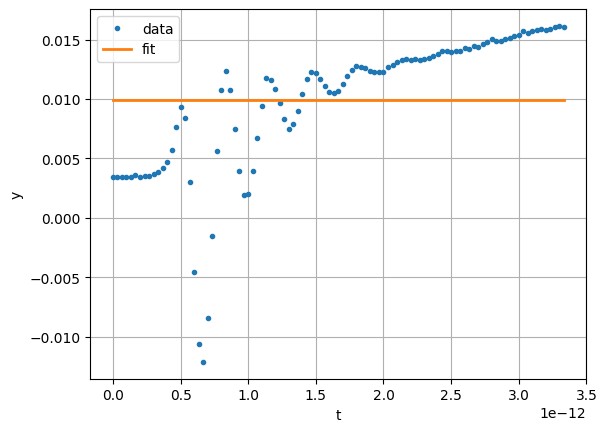

In [31]:
# Data
plt.plot(t, y, 'o', markersize=3, label="data")

# Fit using optimized parameters
plt.plot(t, model3(t, *result.x), '-', linewidth=2, label="fit")

plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

In [32]:
### Second test using a similar method

from scipy.special import erfc

def model_a_conv1(t, a0, a1, tau1, sigma, t0):
    t = np.array(t)

    term = (a1 / 2) * np.exp(
        (sigma**2) / (2 * tau1**2) - (t - t0) / tau1
    ) * erfc(
        (sigma**2 - tau1 * (t - t0)) / (np.sqrt(2) * sigma * tau1)
    )

    return a0 + term


### Model 3 from earlier

# delta_Q0 = Q0[-1] - np.sqrt((-a0-a1)/(2*b)) ## Q0[-1] and b has to become a parameter
params = init_params()

# model_a is replaced by model_a_conv1

def omega_a(a):
    return np.sqrt(-4*a/1)

def delta_Q(a,Q0,b):
    return Q0 - np.sqrt(-a/(2*b))

def phase_from_omega(t, omega):
    dt1 = np.gradient(t)
    return np.cumsum(omega * dt1) + np.pi

def model3(t, t1, d, a1, phi_0, t0, Q0, b, sigma):
    t = np.asarray(t)
    a = model_a_conv1(t, a0, a1, t1, sigma, t0)
    a = np.minimum(a, -1e-12)
    omega = omega_a(a)
    phi = phase_from_omega(t, omega)

    return np.where(
        t < t0,
        Q0,
        Q0 - delta_Q(a,Q0,b) + delta_Q(a,Q0,b) * np.cos(phi + phi_0) * np.exp(-d*(t-t0))
    )

def residuals_explicit3(t1, d, a1, phi_0, t0, Q0, b, sigma, t, data):
    model_vals = model3(t, t1, d, a1, phi_0, t0, Q0, b, sigma)
    return model_vals - data

def residuals_wrapper3(x, t, data):
    t1, d, a1, phi_0, t0, Q0, b, sigma= x
    return residuals_explicit3(t1, d, a1, phi_0, t0, Q0, b, sigma, t, data)

x0 = [9,0.02,1.3,0, 2*(10**(-14)), 0.008, 1, 2e-14]

# x_th = [10,0.024,1,np.pi]

result = least_squares(
    residuals_wrapper3,
    x0,
    args=(t, y),
    bounds=([0, 0, 0, -np.inf, 0, 0, 0,0], [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]),
    loss="soft_l1"
)

t1_fit, d_fit, a1_fit, phi0_fit, t0_fit, Q0_fit, b_fit, sigma_fit = result.x


#t1_th, d_th, a1_th, phi0_th = x_th
#print(t1_th, d_th, a1_th, phi0_th)

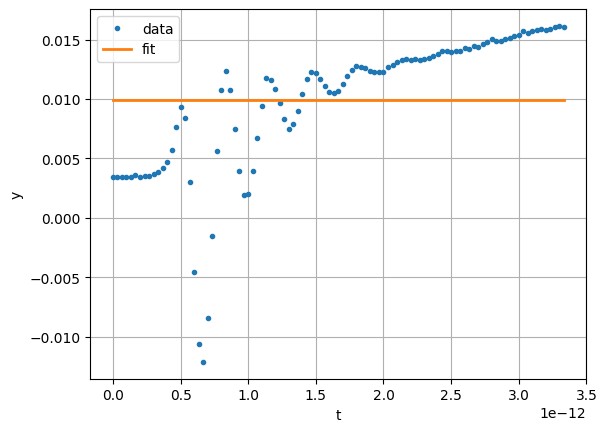

In [33]:
# Data
plt.plot(t, y, 'o', markersize=3, label="data")

# Fit using optimized parameters
plt.plot(t, model3(t, *result.x), '-', linewidth=2, label="fit")

plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

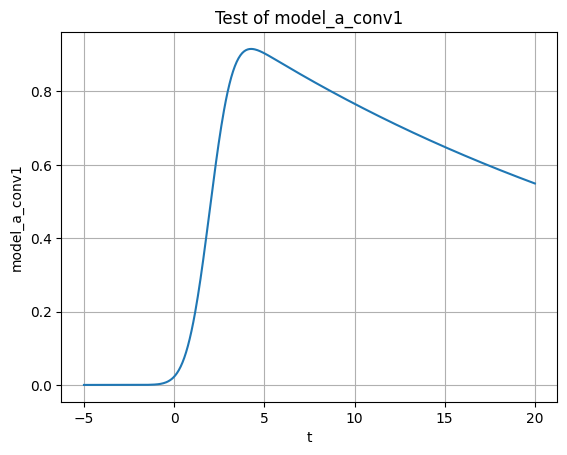

In [34]:
t = np.linspace(-5, 20, 500)

y = model_a_conv1(
    t,
    a0=0,
    a1=1,
    tau1=30,
    sigma=1,
    t0=2
)

plt.figure()
plt.plot(t, y)
plt.xlabel("t")
plt.ylabel("model_a_conv1")
plt.title("Test of model_a_conv1")
plt.grid()
plt.show()